In [ ]:
import pandas as pd
import numpy as np
import sys
from tabulate import tabulate
import matplotlib.pyplot as plt


from pathlib import Path

sys.path.insert(0, str(Path(__file__).parent.parent))


PATH_DATA   = r"C:\Users\pablo.esparcia\Documents\OptionMetrics\output\preliminares\opt_df_prueba.parquet"
print("Cargando datos...")
opt_df = pd.read_parquet(PATH_DATA)

Cargando datos...


In [ ]:
#Añadimos algunas variables de interés:
opt_df["Dummy_Bid"] = opt_df["Bid"] > 0
opt_df["DolarVolume"] = opt_df["Volume"] *opt_df["MidPrice"]

In [ ]:
# Asignamos buckets de vencimientos:
v_grid = [0, 15, 45, 105, 183, 365, np.inf]
v_edges = pd.IntervalIndex.from_breaks(v_grid, closed="right")
opt_df["maturity_bucket"] = pd.cut(opt_df["Days"], bins=v_edges, labels=False, include_lowest=True)

# Asignamos buckets de moneyness (de momento en relación al spot):

m_grid = np.round(np.linspace(0.1,2,int(2/0.1)),2)
m_edges = pd.IntervalIndex.from_breaks(m_grid, closed="right")
opt_df["moneyness_bucket"] = pd.cut(opt_df["Moneyness"], bins=m_edges, labels=False, include_lowest=True)
print(opt_df[["Days", "maturity_bucket", "Moneyness", "moneyness_bucket"]].head(10))
print("Datos cargados y buckets asignados.")

# # In[]

# # Nos quedamos con los vencimientos de 15 a 45 días naturales.
# data_15_45 = opt_df[opt_df["maturity_bucket"] == pd.Interval(15, 45, closed="right")]

#     #También podría hacer: data_15_45 = opt_df[opt_df["Days"].between(15, 45)]


# # In[]


# # Generamos las métricas por grupo de moneyness:
# todos_dias = data_15_45["Date"].unique()
# todos_buckets = data_15_45["moneyness_bucket"].unique()
# idx_completo = pd.MultiIndex.from_product(
#     [todos_buckets, todos_dias], 
#     names=["moneyness_bucket", "Date"]
# )

# # Generamos las métricas por grupo de moneyness con reindex:
# grouped_15_45_v4 = (data_15_45
#     .groupby(["moneyness_bucket", "Date"]).agg(
#         n_contracts  = ("OptionID",      "count"),
#         oi_dsum      = ("OpenInterest",  "sum"),
#         dolvol_dsum  = ("DolarVolume",   "sum"),
#         dbid_dmean   = ("Dummy_Bid",     "mean")
#     )
#     .reindex(idx_completo, fill_value=0) #####Importante esto para asegurar que tenemos filas para todos los días y buckets, incluso si no hay contratos.
#     .reset_index()
# )

# grouped_tabla1_3 = grouped_15_45_v4.groupby("moneyness_bucket").agg(
#     max_n_contracts = ("n_contracts",  "max"),
#     min_n_contracts = ("n_contracts",  "min"),
#     max_oi_dsum     = ("oi_dsum",      "max"),
#     min_oi_dsum     = ("oi_dsum",      "min"),
#     max_dolvol_dsum = ("dolvol_dsum",  "max"),
#     min_dolvol_dsum = ("dolvol_dsum",  "min"),
#     max_dbid_dmean  = ("dbid_dmean",   "max"),
#     min_dbid_dmean  = ("dbid_dmean",   "min")
# ).reset_index()

# grouped_tabla1_3[["max_dbid_dmean", "min_dbid_dmean"]] *= 100
# print(tabulate(grouped_tabla1_3, headers="keys", tablefmt="rounded_outline", floatfmt=".3f", showindex=False))
# # In[]

# # Y si quito OI<=1?


# # Y si quito Bid=0?




# ### No lo hago porque claramente se reduce más.
# # Tan solo notar que en el caso del filtro de OI, aumenta el el Bid_Dummy maximo.

# # In[]
# #Veamos si hay suficiente continuidaad en el panel para cada uno de los buckets de moneyness:



# import matplotlib.pyplot as plt
# # Serie temporal del rango de moneyness cubierto [m_min, m_max] por día (con y sin filtros)

# data_15_45_v2 = data_15_45[data_15_45["Bid"] >=0]

# grouped_15_45 = (data_15_45_v2.groupby(["moneyness_bucket", "Date"]).agg(
#         n_contracts  = ("OptionID",      "count"),
#         oi_dsum      = ("OpenInterest",  "sum"),
#         dolvol_dsum  = ("DolarVolume",   "sum"),
#         dbid_dmean   = ("Dummy_Bid",     "mean")
#     ).reset_index(inplace=False)
# )

# # Serie temporal del rango de moneyness cubierto [m_min, m_max] por día (con y sin filtros)
# rango_moneyness = grouped_15_45.groupby("Date").agg(
#     m_min = ("moneyness_bucket", "min"),
#     m_max = ("moneyness_bucket", "max"),
#     n_buckets = ("moneyness_bucket", "count")
# ).reset_index()

# # Convertir Interval a extremo derecho
# rango_moneyness["m_min"] = rango_moneyness["m_min"].apply(lambda x: x.right)
# rango_moneyness["m_max"] = rango_moneyness["m_max"].apply(lambda x: x.right)


# fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# axes[0].plot(rango_moneyness["Date"], rango_moneyness["m_min"], label="m_min")
# axes[1].plot(rango_moneyness["Date"], rango_moneyness["m_max"], label="m_max")
# axes[2].plot(rango_moneyness["Date"], rango_moneyness["n_buckets"], label="n_buckets", color="green")

# for ax, title in zip(axes, ["Bucket mínimo cubierto", "Bucket máximo cubierto", "Nº buckets con contratos"]):
#     ax.set_title(title)
#     ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()
# # In[]:
# ##################################################################################################################
# # Prueba para diferentes vencimientos 45 a 105 días naturales.:
# ####################################################################################################################

# data_45_105 = opt_df[opt_df["maturity_bucket"] == pd.Interval(45, 105, closed="right")]



# # Generamos las métricas por grupo de moneyness:
# todos_dias = data_45_105["Date"].unique()
# todos_buckets = data_45_105["moneyness_bucket"].unique()
# idx_completo = pd.MultiIndex.from_product(
#     [todos_buckets, todos_dias], 
#     names=["moneyness_bucket", "Date"]
# )

# # Generamos las métricas por grupo de moneyness con reindex:
# grouped_45_105 = (data_45_105
#     .groupby(["moneyness_bucket", "Date"]).agg(
#         n_contracts  = ("OptionID",      "count"),
#         oi_dsum      = ("OpenInterest",  "sum"),
#         dolvol_dsum  = ("DolarVolume",   "sum"),
#         dbid_dmean   = ("Dummy_Bid",     "mean")
#     )
#     .reindex(idx_completo, fill_value=0) #####Importante esto para asegurar que tenemos filas para todos los días y buckets, incluso si no hay contratos.
#     .reset_index()
# )

# grouped_tabla2 = grouped_45_105.groupby("moneyness_bucket").agg(
#     max_n_contracts = ("n_contracts",  "max"),
#     min_n_contracts = ("n_contracts",  "min"),
#     max_oi_dsum     = ("oi_dsum",      "max"),
#     min_oi_dsum     = ("oi_dsum",      "min"),
#     max_dolvol_dsum = ("dolvol_dsum",  "max"),
#     min_dolvol_dsum = ("dolvol_dsum",  "min"),
#     max_dbid_dmean  = ("dbid_dmean",   "max"),
#     min_dbid_dmean  = ("dbid_dmean",   "min")
# ).reset_index()

# grouped_tabla2[["max_dbid_dmean", "min_dbid_dmean"]] *= 100
# print(tabulate(grouped_tabla2, headers="keys", tablefmt="rounded_outline", floatfmt=".3f", showindex=False))

# # Y si quito OI<=1?


# # Y si quito Bid=0?



# #Veamos si hay suficiente continuidaad en el panel para cada uno de los buckets de moneyness:

# import matplotlib.pyplot as plt
# # Serie temporal del rango de moneyness cubierto [m_min, m_max] por día (con y sin filtros)

# data_45_105_v2 = data_45_105[data_45_105["Bid"] >=0]

# grouped_45_105 = (data_45_105_v2.groupby(["moneyness_bucket", "Date"]).agg(
#         n_contracts  = ("OptionID",      "count"),
#         oi_dsum      = ("OpenInterest",  "sum"),
#         dolvol_dsum  = ("DolarVolume",   "sum"),
#         dbid_dmean   = ("Dummy_Bid",     "mean")
#     ).reset_index(inplace=False)
# )

# # Serie temporal del rango de moneyness cubierto [m_min, m_max] por día (con y sin filtros)
# rango_moneyness = grouped_45_105.groupby("Date").agg(
#     m_min = ("moneyness_bucket", "min"),
#     m_max = ("moneyness_bucket", "max"),
#     n_buckets = ("moneyness_bucket", "count")
# ).reset_index()

# # Convertir Interval a extremo derecho
# rango_moneyness["m_min"] = rango_moneyness["m_min"].apply(lambda x: x.right)
# rango_moneyness["m_max"] = rango_moneyness["m_max"].apply(lambda x: x.right)


# fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# axes[0].plot(rango_moneyness["Date"], rango_moneyness["m_min"], label="m_min")
# axes[1].plot(rango_moneyness["Date"], rango_moneyness["m_max"], label="m_max")
# axes[2].plot(rango_moneyness["Date"], rango_moneyness["n_buckets"], label="n_buckets", color="green")

# for ax, title in zip(axes, ["Bucket mínimo cubierto", "Bucket máximo cubierto", "Nº buckets con contratos"]):
#     ax.set_title(title)
#     ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()
# # In[]:
# ##################################################################################################################
# # Prueba para diferentes vencimientos 0 a 15 días naturales.:
# ####################################################################################################################

# data_0_15 = opt_df[opt_df["maturity_bucket"] == pd.Interval(0, 15, closed="right")]



# # Generamos las métricas por grupo de moneyness:
# todos_dias = data_0_15["Date"].unique()
# todos_buckets = data_0_15["moneyness_bucket"].unique()
# idx_completo = pd.MultiIndex.from_product(
#     [todos_buckets, todos_dias], 
#     names=["moneyness_bucket", "Date"]
# )

# # Generamos las métricas por grupo de moneyness con reindex:
# grouped_0_15 = (data_0_15
#     .groupby(["moneyness_bucket", "Date"]).agg(
#         n_contracts  = ("OptionID",      "count"),
#         oi_dsum      = ("OpenInterest",  "sum"),
#         dolvol_dsum  = ("DolarVolume",   "sum"),
#         dbid_dmean   = ("Dummy_Bid",     "mean")
#     )
#     .reindex(idx_completo, fill_value=0) #####Importante esto para asegurar que tenemos filas para todos los días y buckets, incluso si no hay contratos.
#     .reset_index()
# )

# grouped_tabla3 = grouped_0_15.groupby("moneyness_bucket").agg(
#     max_n_contracts = ("n_contracts",  "max"),
#     min_n_contracts = ("n_contracts",  "min"),
#     max_oi_dsum     = ("oi_dsum",      "max"),
#     min_oi_dsum     = ("oi_dsum",      "min"),
#     max_dolvol_dsum = ("dolvol_dsum",  "max"),
#     min_dolvol_dsum = ("dolvol_dsum",  "min"),
#     max_dbid_dmean  = ("dbid_dmean",   "max"),
#     min_dbid_dmean  = ("dbid_dmean",   "min")
# ).reset_index()

# grouped_tabla3[["max_dbid_dmean", "min_dbid_dmean"]] *= 100
# print(tabulate(grouped_tabla3, headers="keys", tablefmt="rounded_outline", floatfmt=".3f", showindex=False))

# # Y si quito OI<=1?


# # Y si quito Bid=0?



# #Veamos si hay suficiente continuidaad en el panel para cada uno de los buckets de moneyness:

# import matplotlib.pyplot as plt
# # Serie temporal del rango de moneyness cubierto [m_min, m_max] por día (con y sin filtros)

# data_0_15_v2 = data_0_15[data_0_15["Bid"] >=0]

# grouped_0_15 = (data_0_15_v2.groupby(["moneyness_bucket", "Date"]).agg(
#         n_contracts  = ("OptionID",      "count"),
#         oi_dsum      = ("OpenInterest",  "sum"),
#         dolvol_dsum  = ("DolarVolume",   "sum"),
#         dbid_dmean   = ("Dummy_Bid",     "mean")
#     ).reset_index(inplace=False)
# )

# # Serie temporal del rango de moneyness cubierto [m_min, m_max] por día (con y sin filtros)
# rango_moneyness = grouped_0_15.groupby("Date").agg(
#     m_min = ("moneyness_bucket", "min"),
#     m_max = ("moneyness_bucket", "max"),
#     n_buckets = ("moneyness_bucket", "count")
# ).reset_index()

# # Convertir Interval a extremo derecho
# rango_moneyness["m_min"] = rango_moneyness["m_min"].apply(lambda x: x.right)
# rango_moneyness["m_max"] = rango_moneyness["m_max"].apply(lambda x: x.right)


# fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# axes[0].plot(rango_moneyness["Date"], rango_moneyness["m_min"], label="m_min")
# axes[1].plot(rango_moneyness["Date"], rango_moneyness["m_max"], label="m_max")
# axes[2].plot(rango_moneyness["Date"], rango_moneyness["n_buckets"], label="n_buckets", color="green")

# for ax, title in zip(axes, ["Bucket mínimo cubierto", "Bucket máximo cubierto", "Nº buckets con contratos"]):
#     ax.set_title(title)
#     ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()
# # In[]:
# ##################################################################################################################
# # Prueba para diferentes vencimientos 105 a 183 días naturales.:
# ####################################################################################################################

# data_105_183 = opt_df[opt_df["maturity_bucket"] == pd.Interval(105, 183, closed="right")]



# # Generamos las métricas por grupo de moneyness:
# todos_dias = data_105_183["Date"].unique()
# todos_buckets = data_105_183["moneyness_bucket"].unique()
# idx_completo = pd.MultiIndex.from_product(
#     [todos_buckets, todos_dias], 
#     names=["moneyness_bucket", "Date"]
# )

# # Generamos las métricas por grupo de moneyness con reindex:
# grouped_105_183 = (data_105_183
#     .groupby(["moneyness_bucket", "Date"]).agg(
#         n_contracts  = ("OptionID",      "count"),
#         oi_dsum      = ("OpenInterest",  "sum"),
#         dolvol_dsum  = ("DolarVolume",   "sum"),
#         dbid_dmean   = ("Dummy_Bid",     "mean")
#     )
#     .reindex(idx_completo, fill_value=0) #####Importante esto para asegurar que tenemos filas para todos los días y buckets, incluso si no hay contratos.
#     .reset_index()
# )

# grouped_tabla4 = grouped_105_183.groupby("moneyness_bucket").agg(
#     max_n_contracts = ("n_contracts",  "max"),
#     min_n_contracts = ("n_contracts",  "min"),
#     max_oi_dsum     = ("oi_dsum",      "max"),
#     min_oi_dsum     = ("oi_dsum",      "min"),
#     max_dolvol_dsum = ("dolvol_dsum",  "max"),
#     min_dolvol_dsum = ("dolvol_dsum",  "min"),
#     max_dbid_dmean  = ("dbid_dmean",   "max"),
#     min_dbid_dmean  = ("dbid_dmean",   "min")
# ).reset_index()

# grouped_tabla4[["max_dbid_dmean", "min_dbid_dmean"]] *= 100
# print(tabulate(grouped_tabla4, headers="keys", tablefmt="rounded_outline", floatfmt=".3f", showindex=False))

# # Y si quito OI<=1?


# # Y si quito Bid=0?



# #Veamos si hay suficiente continuidaad en el panel para cada uno de los buckets de moneyness:

# import matplotlib.pyplot as plt
# # Serie temporal del rango de moneyness cubierto [m_min, m_max] por día (con y sin filtros)

# data_105_183_v2 = data_105_183[data_105_183["Bid"] >=0]

# grouped_105_183 = (data_105_183_v2.groupby(["moneyness_bucket", "Date"]).agg(
#         n_contracts  = ("OptionID",      "count"),
#         oi_dsum      = ("OpenInterest",  "sum"),
#         dolvol_dsum  = ("DolarVolume",   "sum"),
#         dbid_dmean   = ("Dummy_Bid",     "mean")
#     ).reset_index(inplace=False)
# )

# # Serie temporal del rango de moneyness cubierto [m_min, m_max] por día (con y sin filtros)
# rango_moneyness = grouped_105_183.groupby("Date").agg(
#     m_min = ("moneyness_bucket", "min"),
#     m_max = ("moneyness_bucket", "max"),
#     n_buckets = ("moneyness_bucket", "count")
# ).reset_index()

# # Convertir Interval a extremo derecho
# rango_moneyness["m_min"] = rango_moneyness["m_min"].apply(lambda x: x.right)
# rango_moneyness["m_max"] = rango_moneyness["m_max"].apply(lambda x: x.right)


# fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# axes[0].plot(rango_moneyness["Date"], rango_moneyness["m_min"], label="m_min")
# axes[1].plot(rango_moneyness["Date"], rango_moneyness["m_max"], label="m_max")
# axes[2].plot(rango_moneyness["Date"], rango_moneyness["n_buckets"], label="n_buckets", color="green")

# for ax, title in zip(axes, ["Bucket mínimo cubierto", "Bucket máximo cubierto", "Nº buckets con contratos"]):
#     ax.set_title(title)
#     ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

   Days maturity_bucket  Moneyness moneyness_bucket
0    15     (0.0, 15.0]   0.891060       (0.8, 0.9]
1    15     (0.0, 15.0]   0.907561       (0.9, 1.0]
2    15     (0.0, 15.0]   0.935063       (0.9, 1.0]
3    15     (0.0, 15.0]   0.946063       (0.9, 1.0]
4    15     (0.0, 15.0]   0.957064       (0.9, 1.0]
5    15     (0.0, 15.0]   0.962564       (0.9, 1.0]
6    15     (0.0, 15.0]   0.968065       (0.9, 1.0]
7    15     (0.0, 15.0]   0.973565       (0.9, 1.0]
8    15     (0.0, 15.0]   0.979066       (0.9, 1.0]
9    15     (0.0, 15.0]   0.984566       (0.9, 1.0]
Datos cargados y buckets asignados.



=== Vencimiento (0, 15] días ===
╭────────────────────┬───────────────────┬───────────────────┬───────────────┬───────────────┬───────────────────┬───────────────────┬──────────────────┬──────────────────┬──────────────────┬─────────────────╮
│ moneyness_bucket   │   max_n_contracts │   min_n_contracts │   max_oi_dsum │   min_oi_dsum │   max_dolvol_dsum │   min_dolvol_dsum │   max_dbid_dmean │   min_dbid_dmean │   dias_con_datos │   pct_cobertura │
├────────────────────┼───────────────────┼───────────────────┼───────────────┼───────────────┼───────────────────┼───────────────────┼──────────────────┼──────────────────┼──────────────────┼─────────────────┤
│ (0.1, 0.2]         │                12 │                 0 │        131614 │             0 │            11.250 │             0.000 │          100.000 │            0.000 │              867 │          17.705 │
│ (0.2, 0.3]         │                41 │                 0 │        194772 │             0 │      24263500.488 │            

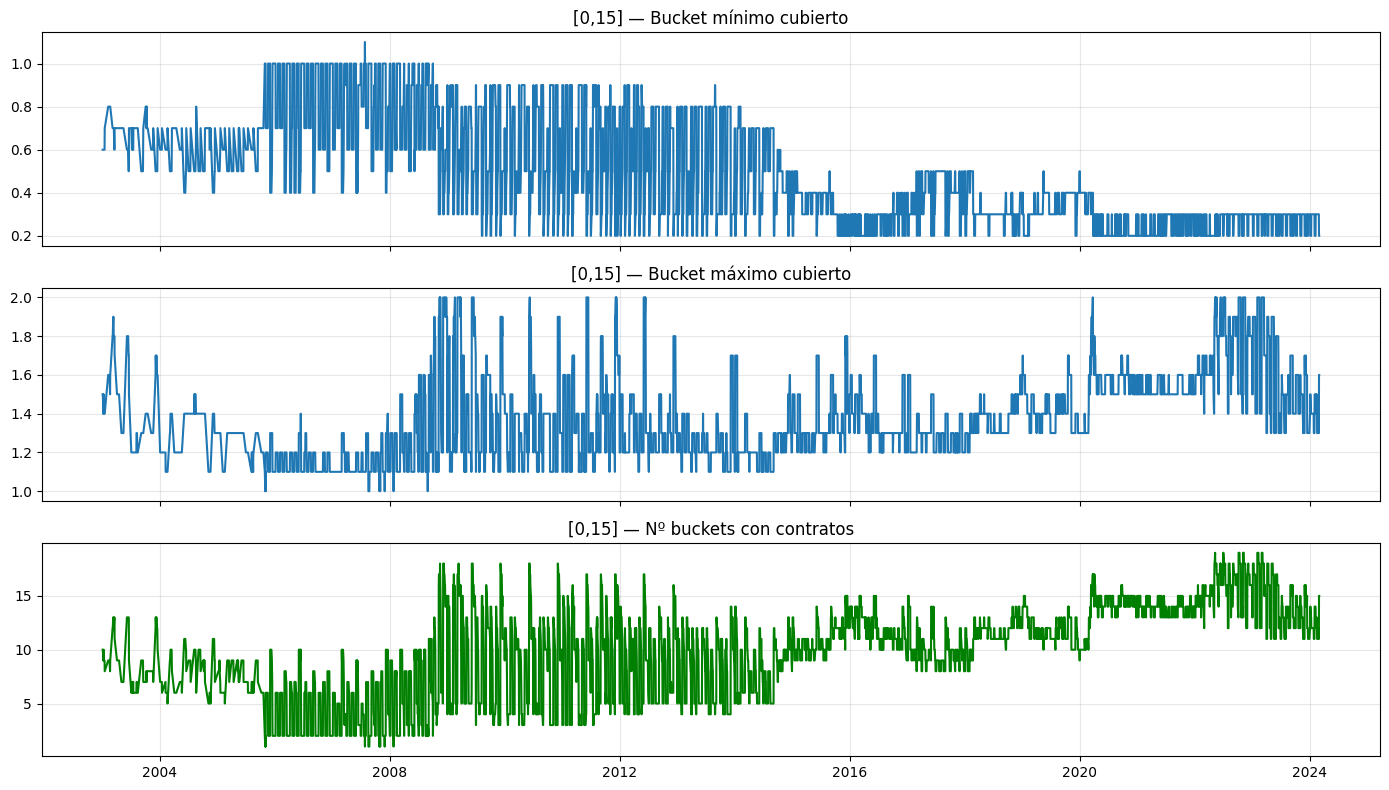


=== Vencimiento (15, 45] días ===
╭────────────────────┬───────────────────┬───────────────────┬───────────────┬───────────────┬───────────────────┬───────────────────┬──────────────────┬──────────────────┬──────────────────┬─────────────────╮
│ moneyness_bucket   │   max_n_contracts │   min_n_contracts │   max_oi_dsum │   min_oi_dsum │   max_dolvol_dsum │   min_dolvol_dsum │   max_dbid_dmean │   min_dbid_dmean │   dias_con_datos │   pct_cobertura │
├────────────────────┼───────────────────┼───────────────────┼───────────────┼───────────────┼───────────────────┼───────────────────┼──────────────────┼──────────────────┼──────────────────┼─────────────────┤
│ (0.1, 0.2]         │                40 │                 0 │        175397 │             0 │       3143139.746 │             0.000 │           80.000 │            0.000 │             2513 │          47.976 │
│ (0.2, 0.3]         │                94 │                 0 │        277993 │             0 │      20623162.040 │           

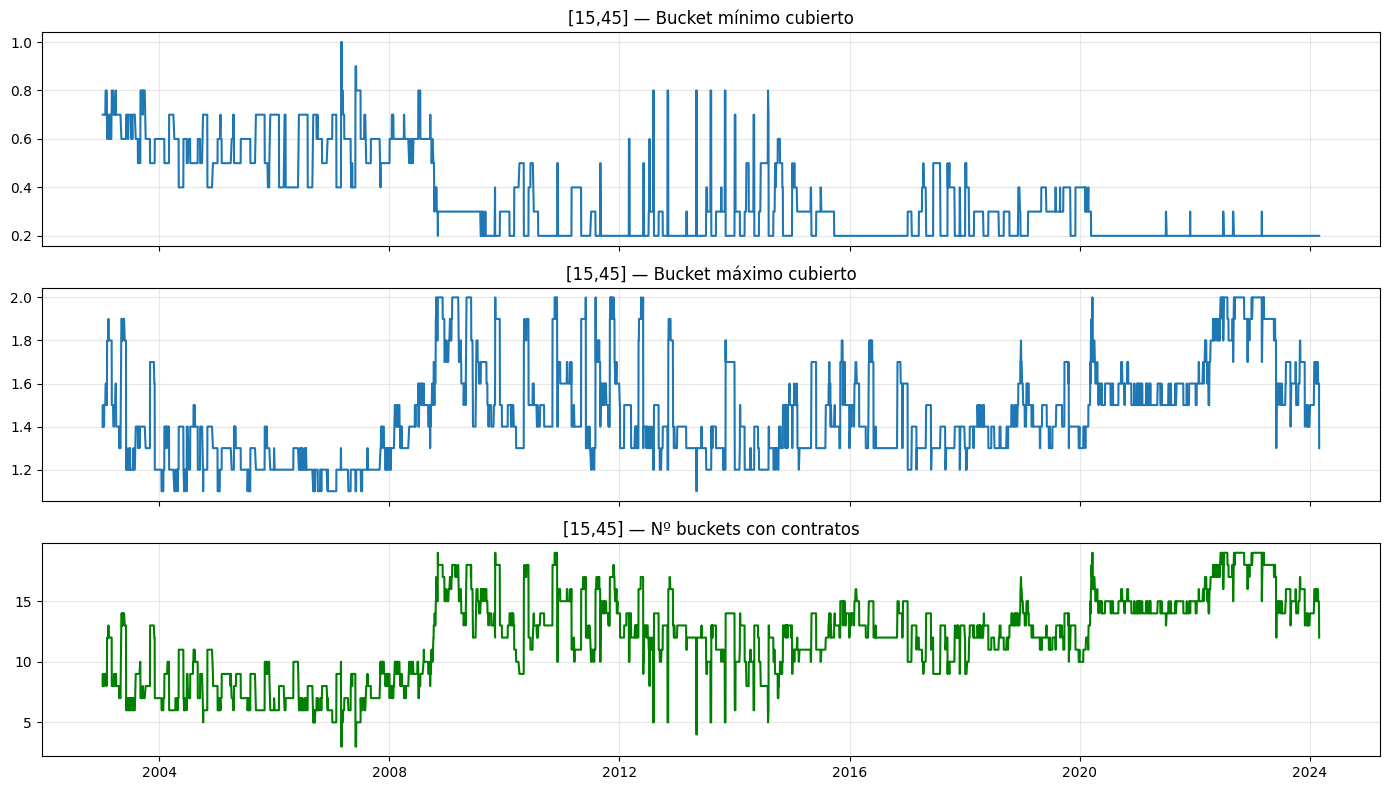


=== Vencimiento (45, 105] días ===
╭────────────────────┬───────────────────┬───────────────────┬───────────────┬───────────────┬───────────────────┬───────────────────┬──────────────────┬──────────────────┬──────────────────┬─────────────────╮
│ moneyness_bucket   │   max_n_contracts │   min_n_contracts │   max_oi_dsum │   min_oi_dsum │   max_dolvol_dsum │   min_dolvol_dsum │   max_dbid_dmean │   min_dbid_dmean │   dias_con_datos │   pct_cobertura │
├────────────────────┼───────────────────┼───────────────────┼───────────────┼───────────────┼───────────────────┼───────────────────┼──────────────────┼──────────────────┼──────────────────┼─────────────────┤
│ (0.1, 0.2]         │                42 │                 0 │        172926 │             0 │      27502474.365 │             0.000 │          100.000 │            0.000 │             2925 │          54.919 │
│ (0.2, 0.3]         │                78 │                 0 │        271644 │             0 │      42320789.037 │          

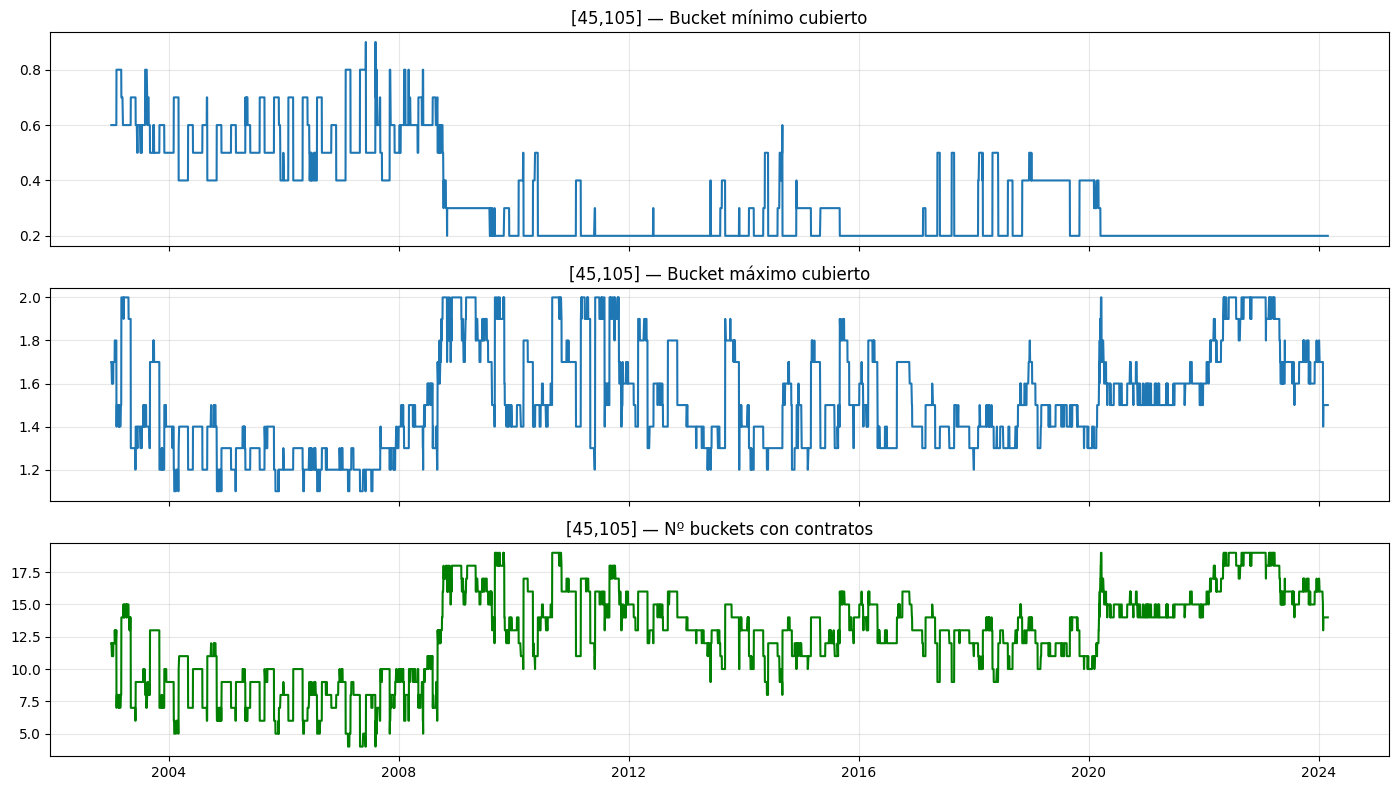


=== Vencimiento (105, 183] días ===
╭────────────────────┬───────────────────┬───────────────────┬───────────────┬───────────────┬───────────────────┬───────────────────┬──────────────────┬──────────────────┬──────────────────┬─────────────────╮
│ moneyness_bucket   │   max_n_contracts │   min_n_contracts │   max_oi_dsum │   min_oi_dsum │   max_dolvol_dsum │   min_dolvol_dsum │   max_dbid_dmean │   min_dbid_dmean │   dias_con_datos │   pct_cobertura │
├────────────────────┼───────────────────┼───────────────────┼───────────────┼───────────────┼───────────────────┼───────────────────┼──────────────────┼──────────────────┼──────────────────┼─────────────────┤
│ (0.1, 0.2]         │                38 │                 0 │        197216 │             0 │      12111599.609 │             0.000 │          100.000 │            0.000 │             3019 │          58.724 │
│ (0.2, 0.3]         │                78 │                 0 │        201049 │             0 │      60348601.758 │         

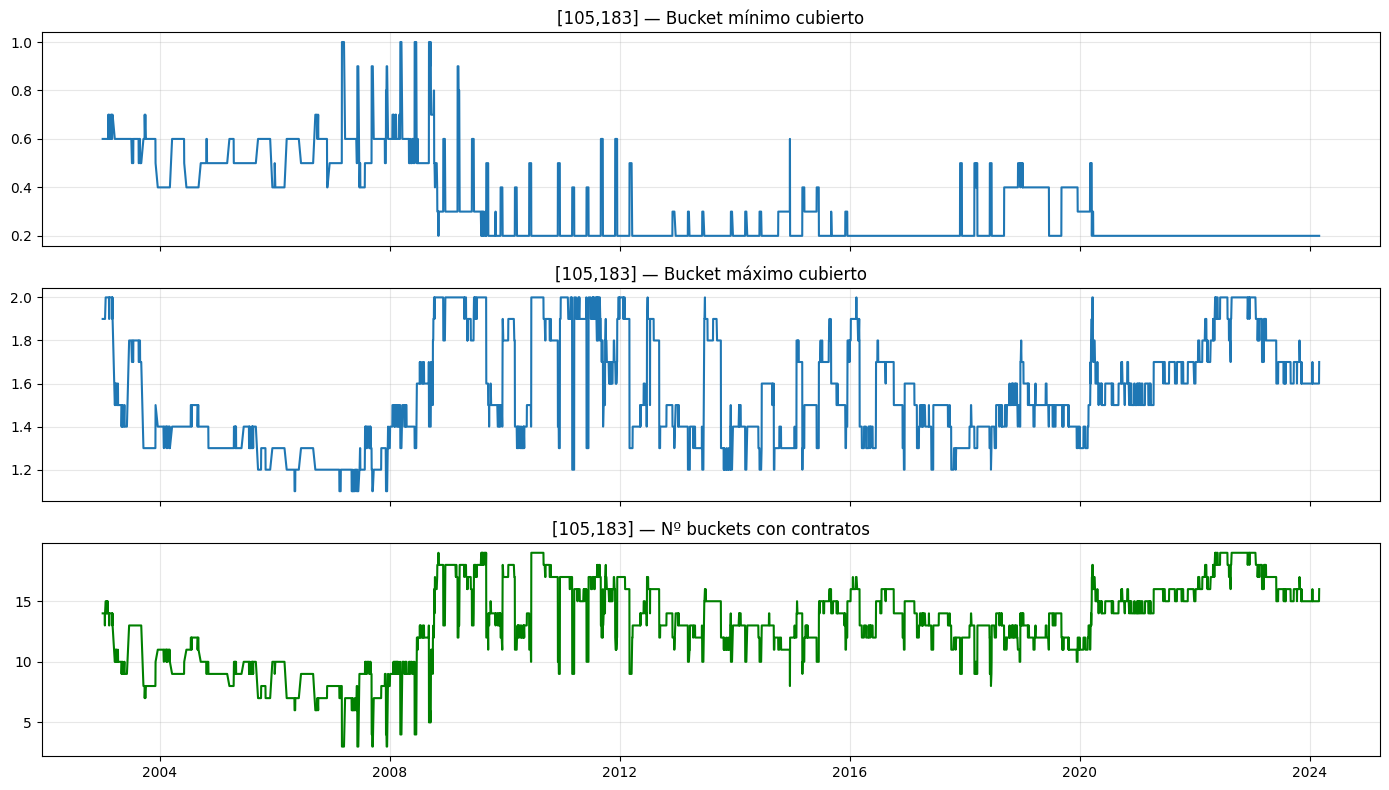


=== Vencimiento (183, 365] días ===
╭────────────────────┬───────────────────┬───────────────────┬───────────────┬───────────────┬───────────────────┬───────────────────┬──────────────────┬──────────────────┬──────────────────┬─────────────────╮
│ moneyness_bucket   │   max_n_contracts │   min_n_contracts │   max_oi_dsum │   min_oi_dsum │   max_dolvol_dsum │   min_dolvol_dsum │   max_dbid_dmean │   min_dbid_dmean │   dias_con_datos │   pct_cobertura │
├────────────────────┼───────────────────┼───────────────────┼───────────────┼───────────────┼───────────────────┼───────────────────┼──────────────────┼──────────────────┼──────────────────┼─────────────────┤
│ (0.1, 0.2]         │                40 │                 0 │        197442 │             0 │       5014076.228 │             0.000 │          100.000 │            0.000 │             3392 │          63.688 │
│ (0.2, 0.3]         │                82 │                 0 │        209892 │             0 │      35308765.542 │         

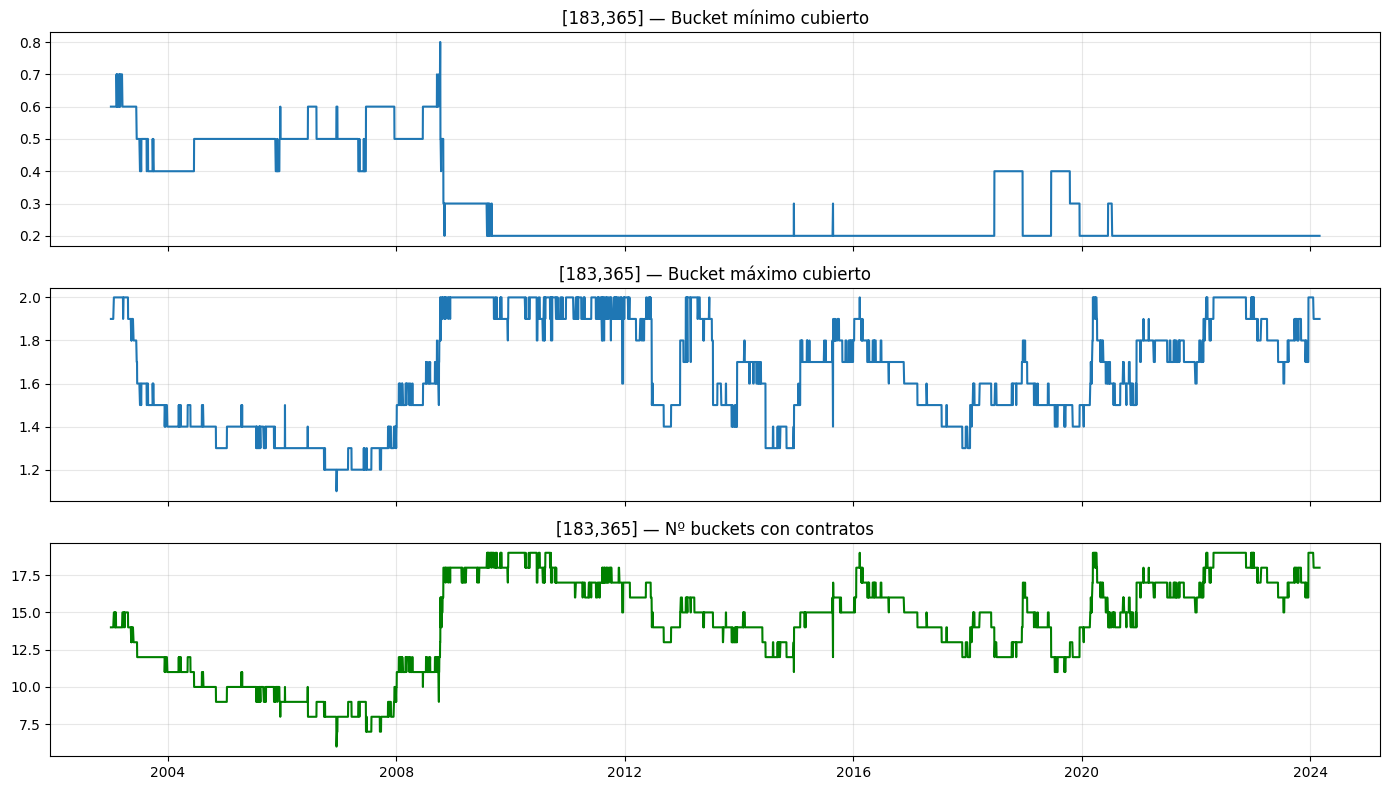

In [ ]:
def analisis_vencimiento(opt_df, v_min, v_max):
    
    nombre = f"{v_min}_{v_max}"
    maturity_interval = pd.Interval(v_min, v_max, closed="right")
    data = opt_df[opt_df["maturity_bucket"] == maturity_interval].copy()
    
    if data.empty:
        print(f"[{nombre}] Sin datos.")
        return None, None, None, None

    # --- Tabla resumen con reindex ---
    todos_dias    = data["Date"].unique()
    todos_buckets = data["moneyness_bucket"].unique()
    idx_completo  = pd.MultiIndex.from_product(
        [todos_buckets, todos_dias],
        names=["moneyness_bucket", "Date"]
    )

    grouped = (data
        .groupby(["moneyness_bucket", "Date"]).agg(
            n_contracts = ("OptionID",     "count"),
            oi_dsum     = ("OpenInterest", "sum"),
            dolvol_dsum = ("DolarVolume",  "sum"),
            dbid_dmean  = ("Dummy_Bid",    "mean")
        )
        .reindex(idx_completo, fill_value=0)
        .reset_index()
    )

    tabla = grouped.groupby("moneyness_bucket").agg(
        max_n_contracts = ("n_contracts",  "max"),
        min_n_contracts = ("n_contracts",  "min"),
        max_oi_dsum     = ("oi_dsum",      "max"),
        min_oi_dsum     = ("oi_dsum",      "min"),
        max_dolvol_dsum = ("dolvol_dsum",  "max"),
        min_dolvol_dsum = ("dolvol_dsum",  "min"),
        max_dbid_dmean  = ("dbid_dmean",   "max"),
        min_dbid_dmean  = ("dbid_dmean",   "min")
    ).reset_index()
    tabla[["max_dbid_dmean", "min_dbid_dmean"]] *= 100

    # --- % de días con cobertura por bucket ---
    total_dias = len(todos_dias)
    cobertura = (grouped[grouped["n_contracts"] > 0]
        .groupby("moneyness_bucket")["Date"]
        .nunique()
        .reset_index()
        .rename(columns={"Date": "dias_con_datos"})
    )
    cobertura["pct_cobertura"] = cobertura["dias_con_datos"] / total_dias * 100
    tabla = tabla.merge(cobertura, on="moneyness_bucket", how="left").fillna(0)

    print(f"\n=== Vencimiento ({v_min}, {v_max}] días ===")
    print(tabulate(tabla, headers="keys", tablefmt="rounded_outline", floatfmt=".3f", showindex=False))

    # --- Continuidad por bucket ---
    fechas_ordenadas = pd.Series(sorted(todos_dias))
    resultados_cont = []
    for bucket, grupo in grouped.groupby("moneyness_bucket"):
        fechas_con_datos = set(grupo[grupo["n_contracts"] > 0]["Date"])
        serie = fechas_ordenadas.isin(fechas_con_datos).astype(int).values
        rachas = []
        racha_actual = 0
        for v in serie:
            if v == 1:
                racha_actual += 1
            else:
                if racha_actual > 0:
                    rachas.append(racha_actual)
                racha_actual = 0
        if racha_actual > 0:
            rachas.append(racha_actual)
        resultados_cont.append({
            "moneyness_bucket": bucket,
            "racha_max":        max(rachas) if rachas else 0,
            "racha_min":        min(rachas) if rachas else 0,
            "racha_media":      np.mean(rachas) if rachas else 0.0,
            "n_rachas":         len(rachas)
        })
    continuidad = pd.DataFrame(resultados_cont)
    print(f"\n=== Continuidad por bucket — ({v_min}, {v_max}] días ===")
    print(tabulate(continuidad, headers="keys", tablefmt="rounded_outline", floatfmt=".1f", showindex=False))

    # --- Gráfico de cobertura ---
    data_bid = data[data["Bid"] >= 0]
    rango = (data_bid
        .groupby(["moneyness_bucket", "Date"]).size()
        .reset_index(name="n")
        .groupby("Date")["moneyness_bucket"]
        .agg(m_min="min", m_max="max", n_buckets="count")
        .reset_index()
    )
    rango["m_min"] = rango["m_min"].apply(lambda x: x.right)
    rango["m_max"] = rango["m_max"].apply(lambda x: x.right)

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    axes[0].plot(rango["Date"], rango["m_min"])
    axes[1].plot(rango["Date"], rango["m_max"])
    axes[2].plot(rango["Date"], rango["n_buckets"], color="green")
    for ax, title in zip(axes, ["Bucket mínimo cubierto", "Bucket máximo cubierto", "Nº buckets con contratos"]):
        ax.set_title(f"[{v_min},{v_max}] — {title}")
        ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

    return tabla, rango, cobertura, continuidad


# --- Ejecución ---
tramos = [(0, 15), (15, 45), (45, 105), (105, 183), (183, 365)]

resultados = {}
for v_min, v_max in tramos:
    tabla, rango, cobertura, continuidad = analisis_vencimiento(opt_df, v_min, v_max)
    resultados[f"{v_min}_{v_max}"] = {
        "tabla": tabla, "rango": rango, 
        "cobertura": cobertura, "continuidad": continuidad
    }



=== Resumen de resultados por tramo de vencimiento con filtro BID>0 ===

=== Vencimiento (0, 15] días ===
╭────────────────────┬───────────────────┬───────────────────┬───────────────┬───────────────┬───────────────────┬───────────────────┬──────────────────┬──────────────────┬──────────────────┬─────────────────╮
│ moneyness_bucket   │   max_n_contracts │   min_n_contracts │   max_oi_dsum │   min_oi_dsum │   max_dolvol_dsum │   min_dolvol_dsum │   max_dbid_dmean │   min_dbid_dmean │   dias_con_datos │   pct_cobertura │
├────────────────────┼───────────────────┼───────────────────┼───────────────┼───────────────┼───────────────────┼───────────────────┼──────────────────┼──────────────────┼──────────────────┼─────────────────┤
│ (0.1, 0.2]         │                 2 │                 0 │          2025 │             0 │             0.000 │             0.000 │          100.000 │            0.000 │               60 │           1.225 │
│ (0.2, 0.3]         │                17 │          

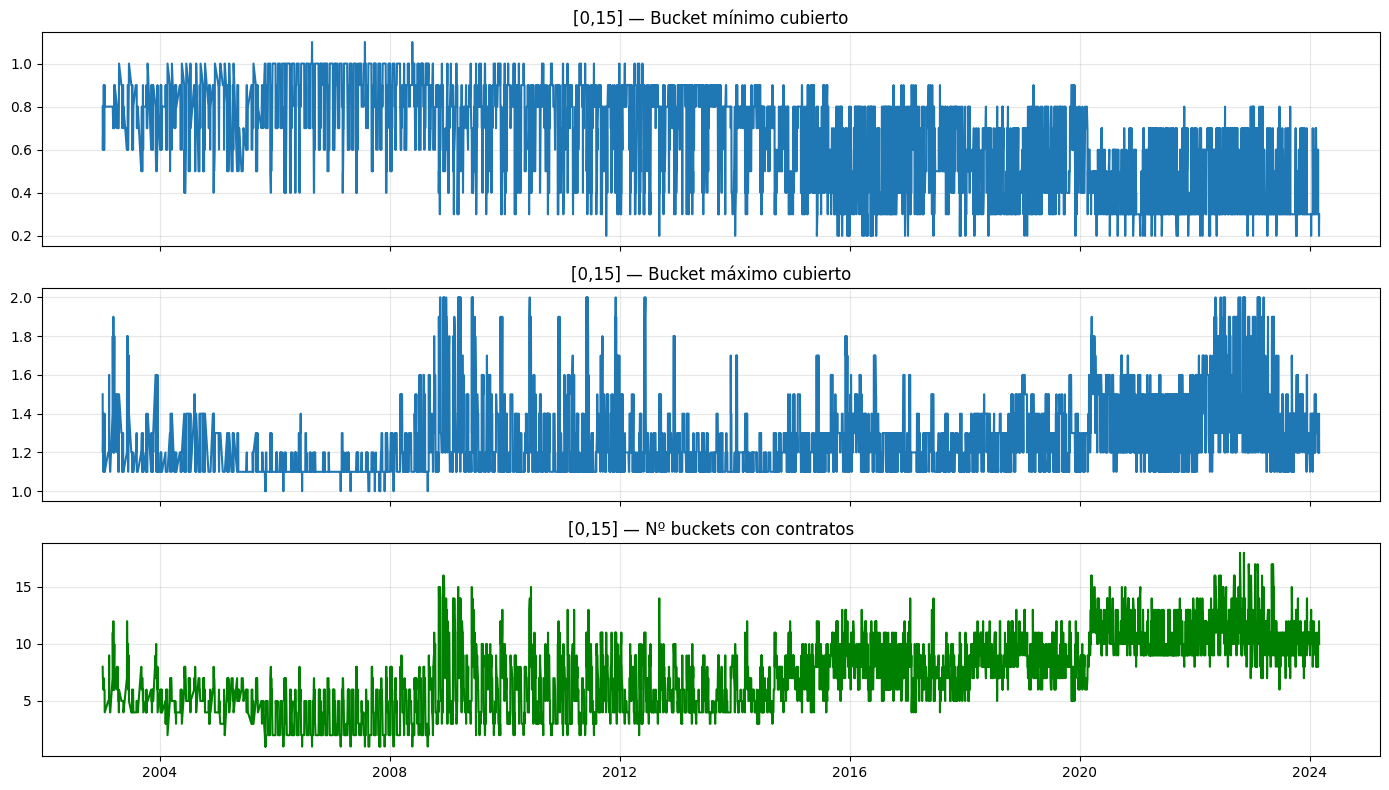


=== Vencimiento (15, 45] días ===
╭────────────────────┬───────────────────┬───────────────────┬───────────────┬───────────────┬───────────────────┬───────────────────┬──────────────────┬──────────────────┬──────────────────┬─────────────────╮
│ moneyness_bucket   │   max_n_contracts │   min_n_contracts │   max_oi_dsum │   min_oi_dsum │   max_dolvol_dsum │   min_dolvol_dsum │   max_dbid_dmean │   min_dbid_dmean │   dias_con_datos │   pct_cobertura │
├────────────────────┼───────────────────┼───────────────────┼───────────────┼───────────────┼───────────────────┼───────────────────┼──────────────────┼──────────────────┼──────────────────┼─────────────────┤
│ (0.1, 0.2]         │                19 │                 0 │         38491 │             0 │       3143139.746 │             0.000 │          100.000 │            0.000 │             1013 │          19.339 │
│ (0.2, 0.3]         │                47 │                 0 │        147980 │             0 │      20623162.040 │           

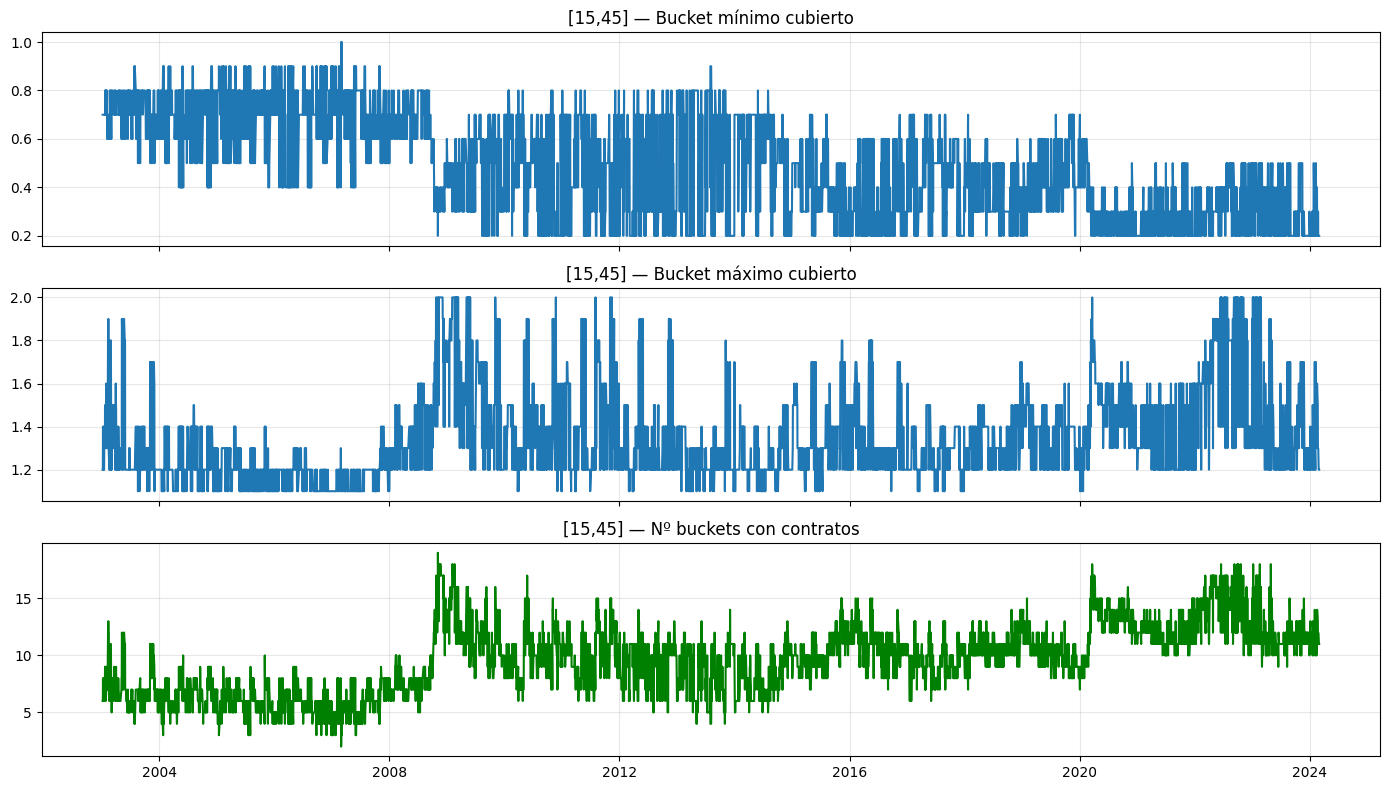


=== Vencimiento (45, 105] días ===
╭────────────────────┬───────────────────┬───────────────────┬───────────────┬───────────────┬───────────────────┬───────────────────┬──────────────────┬──────────────────┬──────────────────┬─────────────────╮
│ moneyness_bucket   │   max_n_contracts │   min_n_contracts │   max_oi_dsum │   min_oi_dsum │   max_dolvol_dsum │   min_dolvol_dsum │   max_dbid_dmean │   min_dbid_dmean │   dias_con_datos │   pct_cobertura │
├────────────────────┼───────────────────┼───────────────────┼───────────────┼───────────────┼───────────────────┼───────────────────┼──────────────────┼──────────────────┼──────────────────┼─────────────────┤
│ (0.1, 0.2]         │                31 │                 0 │        145391 │             0 │      27502474.365 │             0.000 │          100.000 │            0.000 │             1842 │          34.585 │
│ (0.2, 0.3]         │                75 │                 0 │        267612 │             0 │      42320789.037 │          

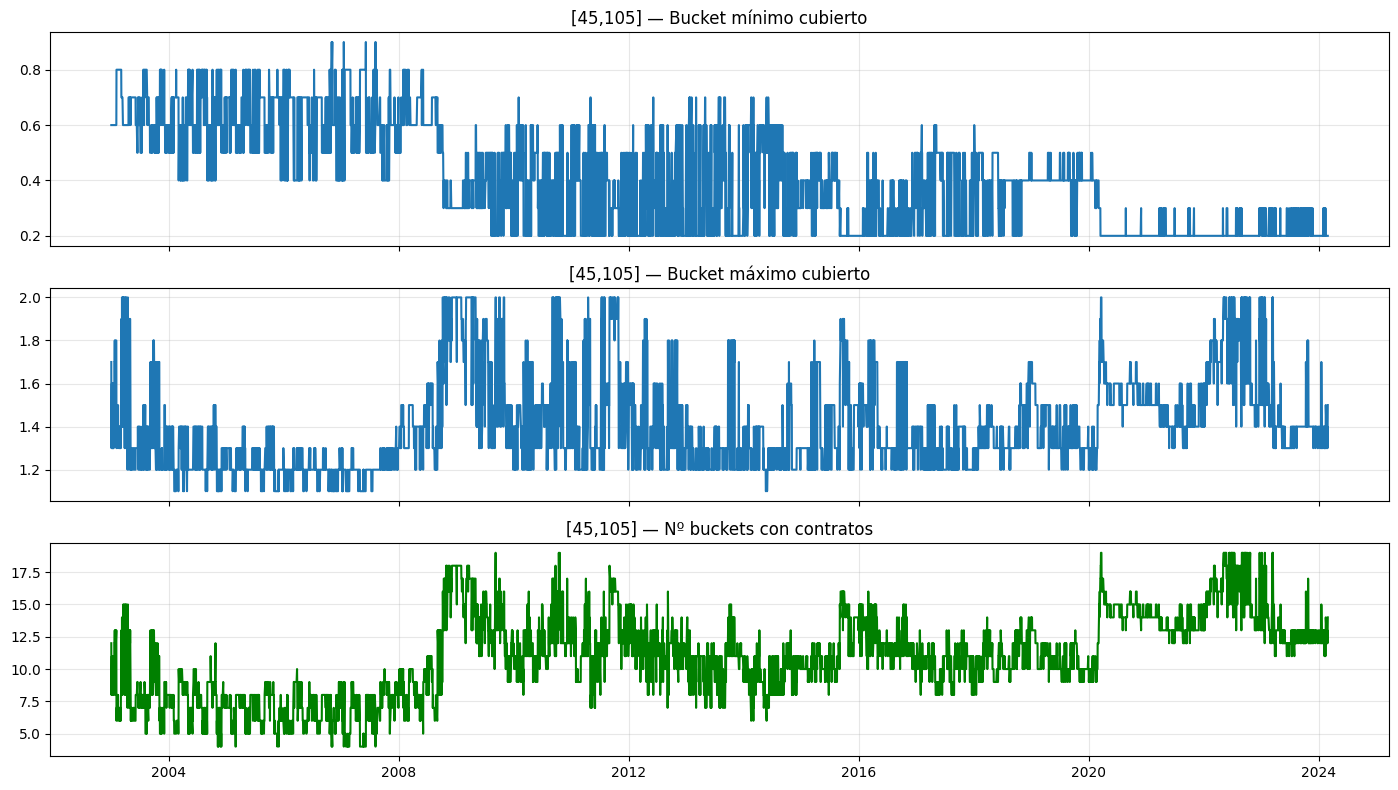


=== Vencimiento (105, 183] días ===
╭────────────────────┬───────────────────┬───────────────────┬───────────────┬───────────────┬───────────────────┬───────────────────┬──────────────────┬──────────────────┬──────────────────┬─────────────────╮
│ moneyness_bucket   │   max_n_contracts │   min_n_contracts │   max_oi_dsum │   min_oi_dsum │   max_dolvol_dsum │   min_dolvol_dsum │   max_dbid_dmean │   min_dbid_dmean │   dias_con_datos │   pct_cobertura │
├────────────────────┼───────────────────┼───────────────────┼───────────────┼───────────────┼───────────────────┼───────────────────┼──────────────────┼──────────────────┼──────────────────┼─────────────────┤
│ (0.1, 0.2]         │                38 │                 0 │         88406 │             0 │      12111599.609 │             0.000 │          100.000 │            0.000 │             1957 │          38.067 │
│ (0.2, 0.3]         │                78 │                 0 │        196204 │             0 │      60348601.758 │         

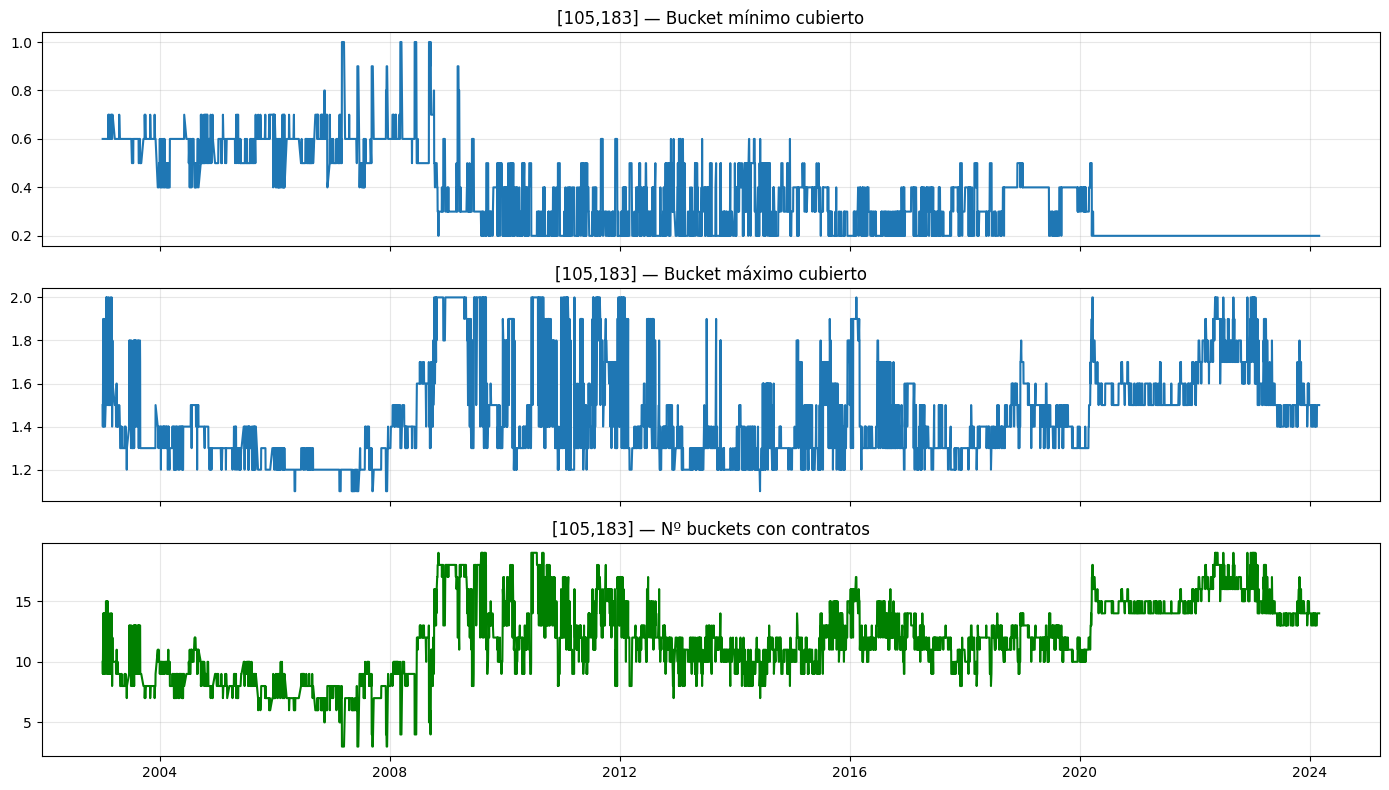


=== Vencimiento (183, 365] días ===
╭────────────────────┬───────────────────┬───────────────────┬───────────────┬───────────────┬───────────────────┬───────────────────┬──────────────────┬──────────────────┬──────────────────┬─────────────────╮
│ moneyness_bucket   │   max_n_contracts │   min_n_contracts │   max_oi_dsum │   min_oi_dsum │   max_dolvol_dsum │   min_dolvol_dsum │   max_dbid_dmean │   min_dbid_dmean │   dias_con_datos │   pct_cobertura │
├────────────────────┼───────────────────┼───────────────────┼───────────────┼───────────────┼───────────────────┼───────────────────┼──────────────────┼──────────────────┼──────────────────┼─────────────────┤
│ (0.1, 0.2]         │                40 │                 0 │        194579 │             0 │       5014076.228 │             0.000 │          100.000 │            0.000 │             2734 │          51.333 │
│ (0.2, 0.3]         │                82 │                 0 │        209892 │             0 │      35308765.542 │         

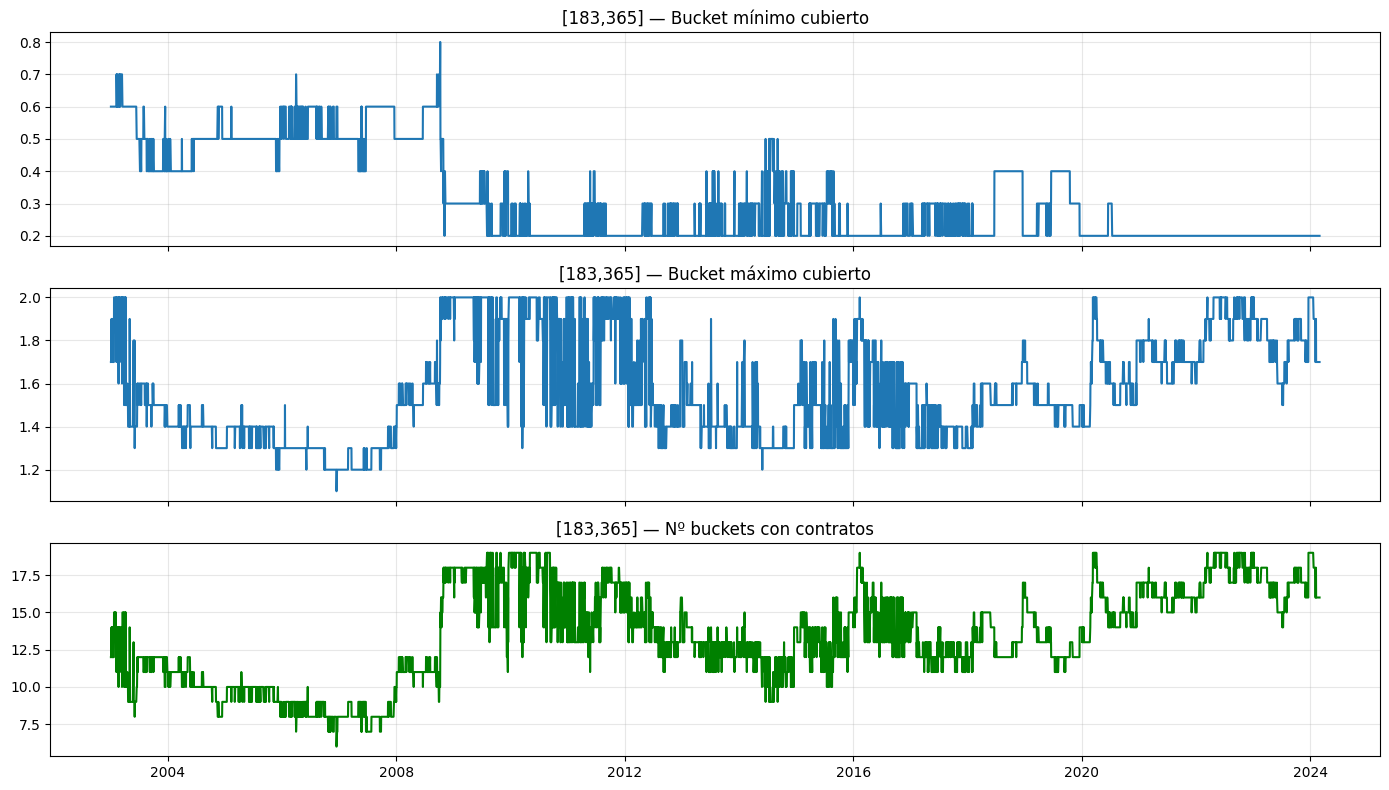

In [ ]:
print("\n\n=== Resumen de resultados por tramo de vencimiento con filtro BID>0 ===")
# --- Ejecución ---

opt_df2 = opt_df[opt_df["Bid"] > 0]
resultados = {}
for v_min, v_max in tramos:
    tabla, rango, cobertura, continuidad = analisis_vencimiento(opt_df2, v_min, v_max)
    resultados[f"{v_min}_{v_max}"] = {
        "tabla": tabla, "rango": rango, 
        "cobertura": cobertura, "continuidad": continuidad
    }